<a href="https://colab.research.google.com/github/urfavjason/Personal/blob/main/Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Loại Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [ ]:
df_campaign = pd.read_csv('/content/drive/MyDrive/bofbznaa76gciz4z0bdviecgybki/movie_ticket_data/campaign.csv')
df_customer = pd.read_csv('/content/drive/MyDrive/bofbznaa76gciz4z0bdviecgybki/movie_ticket_data/customer.csv')
df_device = pd.read_csv('/content/drive/MyDrive/bofbznaa76gciz4z0bdviecgybki/movie_ticket_data/device_detail.csv')
df_status = pd.read_csv('/content/drive/MyDrive/bofbznaa76gciz4z0bdviecgybki/movie_ticket_data/status_detail.csv')
df_ticket = pd.read_csv('/content/drive/MyDrive/bofbznaa76gciz4z0bdviecgybki/movie_ticket_data/ticket_history.csv')

#**2. Data cleaning**

##2.1 Data type, Null values, Duplicate values

In [ ]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  131400 non-null  int64 
 1   usergender   131400 non-null  object
 2   dob          131400 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.0+ MB


In [ ]:
# chuyển đổi data type của dob thành datetime
from datetime import datetime
df_customer['dob'] = pd.to_datetime(df_customer['dob'])

In [ ]:
# kiểm tra giá trị trùng
df_customer.duplicated().sum()

np.int64(0)

In [ ]:
# Bảng campaign
df_campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   campaign_id    216 non-null    int64 
 1   campaign_type  216 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [ ]:
df_campaign.head(2)

,campaign_id,campaign_type
0,106460,direct discount
1,30040,direct discount


In [ ]:
df_campaign.duplicated().sum()

np.int64(0)

In [ ]:
# Bảng device
df_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139902 entries, 0 to 139901
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   device_number  139901 non-null  object
 1   model          132763 non-null  object
 2   platform       139902 non-null  object
dtypes: object(3)
memory usage: 3.2+ MB


In [ ]:
# create func calculate NULL rate of each column
def calc_null_rate(df):
    newdf = df.isnull().sum().to_frame('null_count')
    newdf[['null_rate']] = newdf[['null_count']] / len(df)
    return newdf.sort_values(by=['null_rate'], ascending=False)

In [ ]:
calc_null_rate(df_device)

,null_count,null_rate
model,7139,0.051029
device_number,1,0.000007
platform,0,0.000000


In [ ]:
df_device = df_device.fillna({'model':'unknown'})
df_device = df_device[df_device['device_number'].notna()]

In [ ]:
calc_null_rate(df_device)

,null_count,null_rate
device_number,0,0.0
model,0,0.0
platform,0,0.0


In [ ]:
# bảng status
df_status.head(10)

,status_id,description,error_group
0,1,Order successful,NaN
1,-1,Payment overdue,customer
2,-2,Insufficient funds in customer account. Please add more funds and try the transaction again.,customer
3,-3,No response from your bank,external
4,-4,Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.,customer
5,-5,Payment failed from bank,external
6,-6,Need verify your account to continue,customer
7,-7,Transaction temporarily limited,internal


In [ ]:
# bảng ticket
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154827 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ticket_id       154827 non-null  object 
 1   customer_id     154827 non-null  int64  
 2   paying_method   154827 non-null  object 
 3   theater_name    154827 non-null  float64
 4   device_number   154827 non-null  object 
 5   original_price  154827 non-null  float64
 6   discount_value  154827 non-null  float64
 7   final_price     154827 non-null  float64
 8   time            154827 non-null  object 
 9   status_id       154827 non-null  int64  
 10  campaign_id     154827 non-null  int64  
 11  movie_name      154827 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 14.2+ MB


In [ ]:
df_ticket.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder


In [ ]:
# Thay đổi data type của cột time
df_ticket['time'] = pd.to_datetime(df_ticket['time'])

In [ ]:
calc_null_rate(df_ticket)

,null_count,null_rate
ticket_id,0,0.0
customer_id,0,0.0
paying_method,0,0.0
theater_name,0,0.0
device_number,0,0.0
original_price,0,0.0
discount_value,0,0.0
final_price,0,0.0
time,0,0.0
status_id,0,0.0


In [ ]:
df_ticket['ticket_id'].nunique()

154725

In [ ]:
df_dup = df_ticket[df_ticket.duplicated(keep = False)]

In [ ]:
df_dup.head(10)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name
3555,c56e3eb9fb1fd241c9de7a700d7a52d2,206709,money in app,5.0,291f6a5c77b7d98a86fe76bdbabe94eb,5.77,1.03,4.74,2022-07-02 22:11:30.005,1,85940,Thor: Love And Thunder
3556,c56e3eb9fb1fd241c9de7a700d7a52d2,206709,money in app,5.0,291f6a5c77b7d98a86fe76bdbabe94eb,5.77,1.03,4.74,2022-07-02 22:11:30.005,1,85940,Thor: Love And Thunder
49730,763e20c9c1136c5c06d9a960fac9dae6,174180,credit card,29.0,ba5794fca2cba47fd0141dd3fb195934,7.42,0.00,7.42,2019-12-23 15:28:45.738,1,0,Dreamy Eyes
49731,763e20c9c1136c5c06d9a960fac9dae6,174180,credit card,29.0,ba5794fca2cba47fd0141dd3fb195934,7.42,0.00,7.42,2019-12-23 15:28:45.738,1,0,Dreamy Eyes
49876,257d0a0e6a7f38b90b5ecdfa9e8416b9,133912,money in app,119.0,18abc497c03f7e6bd0b0cf72a89fb911,7.42,0.00,7.42,2019-12-23 18:04:51.790,1,0,Dreamy Eyes
49877,257d0a0e6a7f38b90b5ecdfa9e8416b9,133912,money in app,119.0,18abc497c03f7e6bd0b0cf72a89fb911,7.42,0.00,7.42,2019-12-23 18:04:51.790,1,0,Dreamy Eyes
50202,6dec59a668243f07301d5bf3c2368fa0,111474,debit card,109.0,a07a8e335cc40b1e39e2d7fc9a9af557,8.66,0.00,8.66,2019-12-23 10:35:45.542,1,0,Dreamy Eyes
50203,6dec59a668243f07301d5bf3c2368fa0,111474,debit card,109.0,a07a8e335cc40b1e39e2d7fc9a9af557,8.66,0.00,8.66,2019-12-23 10:35:45.542,1,0,Dreamy Eyes
50212,5f377be63fca730d5b5d12e06ac3f05d,117355,credit card,53.0,9092a5b635cbcf89633ff48766bc04e6,7.84,0.00,7.84,2019-12-23 19:30:23.767,1,0,Dreamy Eyes
50213,5f377be63fca730d5b5d12e06ac3f05d,117355,credit card,53.0,9092a5b635cbcf89633ff48766bc04e6,7.84,0.00,7.84,2019-12-23 19:30:23.767,1,0,Dreamy Eyes


In [ ]:
df_ticket.drop_duplicates(inplace = True)

In [ ]:
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154725 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticket_id       154725 non-null  object        
 1   customer_id     154725 non-null  int64         
 2   paying_method   154725 non-null  object        
 3   theater_name    154725 non-null  float64       
 4   device_number   154725 non-null  object        
 5   original_price  154725 non-null  float64       
 6   discount_value  154725 non-null  float64       
 7   final_price     154725 non-null  float64       
 8   time            154725 non-null  datetime64[ns]
 9   status_id       154725 non-null  int64         
 10  campaign_id     154725 non-null  int64         
 11  movie_name      154725 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 15.3+ MB


##**2.2 Join tables**

In [ ]:
# Xuất phát từ bảng ticket để join với các dimension còn lại
df_campaign_join = pd.merge(df_ticket, df_campaign, on = 'campaign_id', how = 'left')
df_customer_join = pd.merge(df_campaign_join, df_customer, on = 'customer_id', how = 'left')
df_device_join = pd.merge(df_customer_join, df_device, on = 'device_number', how = 'left')
df_join_all = pd.merge(df_device_join, df_status, on = 'status_id', how = 'left')

In [ ]:
df_join_all.count()

,0
ticket_id,154725
customer_id,154725
paying_method,154725
theater_name,154725
device_number,154725
original_price,154725
discount_value,154725
final_price,154725
time,154725
status_id,154725


In [ ]:
df_join_all = df_join_all.fillna('unknown')

In [ ]:
calc_null_rate(df_join_all)

,null_count,null_rate
ticket_id,0,0.0
customer_id,0,0.0
paying_method,0,0.0
theater_name,0,0.0
device_number,0,0.0
original_price,0,0.0
discount_value,0,0.0
final_price,0,0.0
time,0,0.0
status_id,0,0.0


##**2.3 View all values of each column**

In [ ]:
df_join_all.nunique().sort_values(ascending=False)

,0
ticket_id,154725
time,154725
device_number,126459
customer_id,119477
dob,11322
final_price,2715
original_price,1895
model,1215
movie_name,253
discount_value,242


In [ ]:
specific_cols = ['movie_name','description','paying_method','campaign_type','usergender','platform', 'error_group']
for col in specific_cols:
    print(col + ' : ', np.sort(df_join_all[col].unique().astype(str)))
    print('\r')
    print('--------------------------')
    print('\r')

movie_name :  ['13rd Sister' '13rd Sister: Three Deadly Days' '1990' '2037'
 '30 Chua Phai Tet' '47 Meters Down: Uncaged' 'A Chamada Da Selva'
 'A Diamond In The Rough' 'Accidentally Dad' 'Aladdin' 'Alienoid'
 'Alita: Battle Angel' 'Ambulance' 'Anchor' 'Angel Has Fallen' 'Anna'
 'Annabelle Comes Home' 'Aquaman' 'Around The World In 80 Days'
 'Autumn Promise' 'Avatar' 'Avatar: The Way Of Water' 'Avengers: Endgame'
 'Bad Boys For Life' 'Batman' 'Beast' 'Birds Of Prey' 'Black Adam'
 'Black Panther 2: Wakanda Forever' 'Black Panther: Wakanda Forever'
 'Blood Karma' 'Blood Moon Party' 'Bloodshot' 'Broker' 'Bullet Train'
 'Bumblebee' 'Bắc Kim Thang' 'Camellia Sisters' 'Captain Marvel'
 "Charlie's Angels" 'Cherry Magic The Movie Thirty Years'
 'Chickenhare And The Hamster Of Darkness' 'Chuyện Ma Đô Thị' 'Collectors'
 'Concessions' 'Confidential Assignment 2: International' 'Cracked'
 'Crawl' 'Crazy Romance' "Dad I'm Sorry" 'Daddy Issues' 'Daeng'
 'Dark Figure Of Crime' 'Dc League Of Super-Pet

#**3. Analyze**

##3.1 Customer portrait

###Age and Gender distribution

In [ ]:
df_join_all.head()

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,usergender,dob,model,platform,description,error_group
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,Male,1989-02-25,"iPhone13,1",mobile,Order successful,unknown
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,Male,1991-06-09,browser,website,Order successful,unknown
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unknown,Male,1989-05-18,unknown,mobile,Order successful,unknown
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,Male,1997-08-31,devicemodel,mobile,Order successful,unknown
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,Male,1988-09-20,devicemodel,mobile,Order successful,unknown


In [ ]:
# Tính số tuổi
current_date = datetime.now()
df_join_all['age_days'] = (current_date - df_join_all['dob']).dt.days
df_join_all['age'] = df_join_all['age_days'] / 365
df_join_all['age'] = df_join_all['age'].astype(int)

In [ ]:
# Lấy ra danh sách KH kèm theo age và gender
df_cus = df_join_all.drop_duplicates(subset=['customer_id'])[['customer_id','dob','usergender','age']]

In [ ]:
df_cus.count()

,0
customer_id,119477
dob,119477
usergender,119477
age,119477


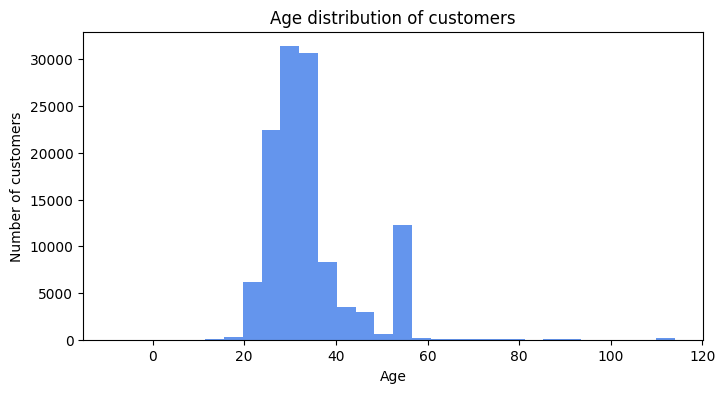

In [ ]:
# Phân bố khách hàng theo độ tuổi
plt.figure(figsize=(8,4))
df_cus['age'].hist(bins=30,color='cornflowerblue', grid = False)
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.title('Age distribution of customers')
plt.show()

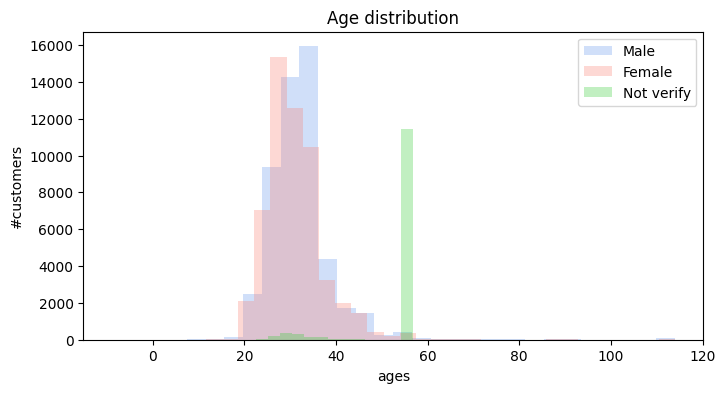

In [ ]:
# Phân bổ độ tuổi theo nhóm giới tính :
plt.figure(figsize=(8,4))

## data
male_age = df_cus[df_cus['usergender'] == 'Male']['age']
female_age = df_cus[df_cus['usergender'] == 'Female']['age']
unknown_age = df_cus[df_cus['usergender'] == 'Not verify']['age']

## plot
plt.hist(male_age, bins=30, alpha = 0.3, color = 'cornflowerblue', label = 'Male')
plt.hist(female_age, bins=30, alpha = 0.3, color = 'salmon', label = 'Female')
plt.hist(unknown_age, bins=30, alpha = 0.3, color = 'limegreen', label = 'Not verify')

##edit
plt.title('Age distribution')
plt.xlabel('ages')
plt.ylabel('#customers')
plt.legend()
plt.show()

In [ ]:
# Đánh giá chi tiết nhóm Not Verify
df_gen = df_cus.groupby('usergender').agg(total=('customer_id','count')).sort_values(by='total', ascending=False).reset_index()
df_gen

,usergender,total
0,Female,55689
1,Male,50873
2,Not verify,12915


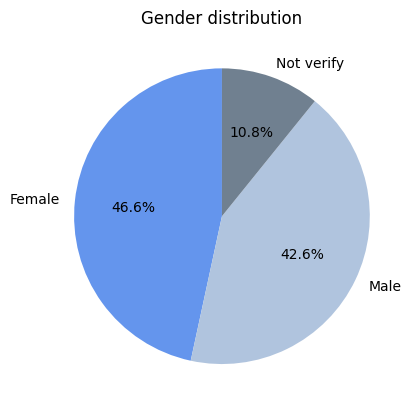

In [ ]:
# Visualize
plt.pie(df_gen['total'], labels=df_gen['usergender'], autopct='%1.1f%%', colors=['cornflowerblue','lightsteelblue','slategrey'],startangle=90)
plt.title('Gender distribution')
plt.show()

In [ ]:
df_cus[df_cus['usergender']=='Not verify'].groupby('age').agg(number=('customer_id','count')).sort_values(by='number',ascending=False).reset_index().head(10)

,age,number
0,56,11435
1,30,126
2,31,122
3,32,114
4,28,110
5,29,107
6,27,101
7,33,101
8,26,96
9,34,95


>**Notes**
>- Nhóm khách hàng chưa verify tài khoản chiếm 10.8%, dẫn đến 2 trường hợp:
>>- Nếu họ nhập dob thì sẽ có data
>>- Nếu họ không nhập dob thì hệ thống sẽ auto fill là 1970 --> 54 tuổi









###**Age generation distribution**

In [ ]:
df_cus.head(2)

,customer_id,dob,usergender,age
0,100009,1989-02-25,Male,37
1,100493,1991-06-09,Male,34


In [ ]:
# Logic phân loại X, Y, Z, Baby --> Dựa vào năm sinh
df_cus['age_generation'] = df_cus['dob'].apply(lambda x: 'Baby Boomer' if x.year <= 1964 else ('Gen X' if x.year <= 1980 else ('Gen Y' if x.year <= 1996 else 'Gen Z')))

In [ ]:
df_gen_group = df_cus[df_cus['usergender']!='Not verify'].groupby('age_generation').agg(total=('customer_id','count')).sort_values(by='total',ascending = False).reset_index()
df_gen_group

,age_generation,total
0,Gen Y,63310
1,Gen Z,38401
2,Gen X,4261
3,Baby Boomer,590


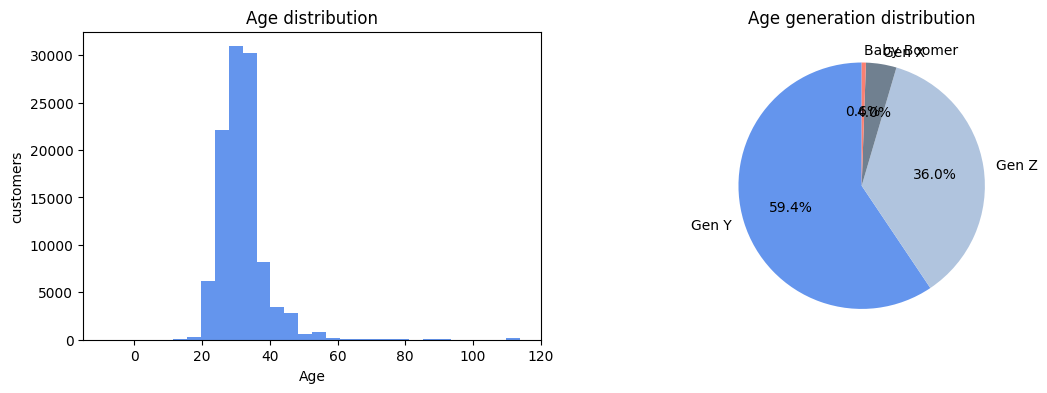

In [ ]:
# Kết hợp 2 biểu đồ
plt.figure(figsize=(13, 4))

# plot 1
ax1 = plt.subplot(1,2,1)
df_cus[df_cus['usergender']!='Not verify']['age'].hist(bins=30,color='cornflowerblue', grid = False)
plt.xlabel('Age')
plt.ylabel('customers')
plt.title('Age distribution')

ax2 = plt.subplot(1,2,2)
plt.pie(df_gen_group['total'], labels=df_gen_group['age_generation'], autopct='%1.1f%%', colors=['cornflowerblue','lightsteelblue','slategrey','salmon'],startangle=90)
plt.title('Age generation distribution')

plt.show()


##**3.2 Time series data - When dis customers buy tickets ?**

###**Trend by month**

In [ ]:
df_join_all['month'] = pd.to_datetime(df_join_all['time']).dt.month
df_join_all['day_name'] = pd.to_datetime(df_join_all['time']).dt.day_name()
df_join_all['hour'] = pd.to_datetime(df_join_all['time']).dt.hour
df_join_all['year_month'] = pd.to_datetime(df_join_all['time']).dt.strftime('%Y-%m')

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,usergender,dob,model,platform,description,error_group,age_days,age,month,day_name,hour,year_month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,Male,1989-02-25,"iPhone13,1",mobile,Order successful,unknown,13608,37,7,Friday,17,2022-07
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,Male,1991-06-09,browser,website,Order successful,unknown,12774,34,7,Friday,20,2022-07


In [ ]:
# Thống kê theo tháng
df_time_month = df_join_all.groupby('year_month').agg(
    total_tickets=('ticket_id','count'),
).reset_index()

In [ ]:
df_time_month.head()

,year_month,total_tickets
0,2019-01,2019
1,2019-02,1626
2,2019-03,1004
3,2019-04,4069
4,2019-05,4430


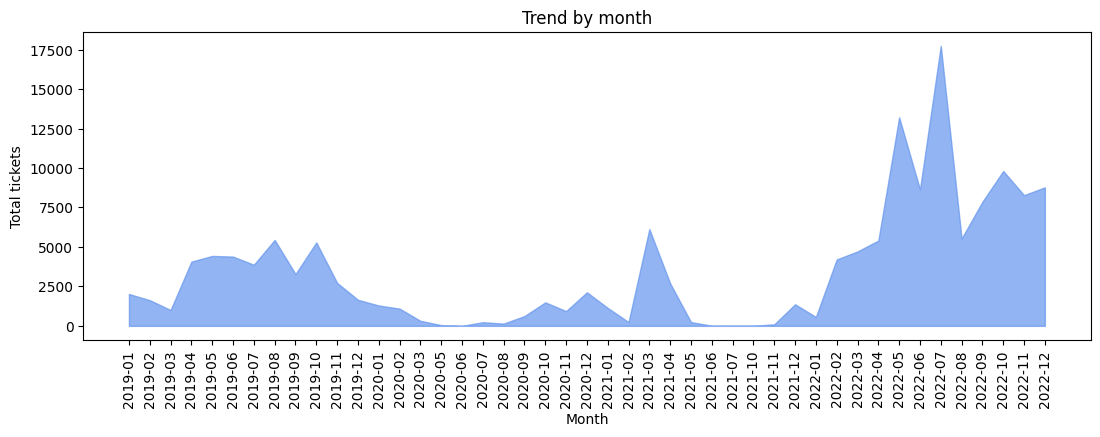

In [ ]:
# Vẽ biểu đồ miền theo tháng

plt.figure(figsize=(13, 4))
plt.fill_between(df_time_month['year_month'], df_time_month['total_tickets'], alpha=0.7 , color='cornflowerblue')
plt.xticks(rotation=90)
plt.xlabel('Month')
plt.ylabel('Total tickets')
plt.title('Trend by month')
plt.show()

In [ ]:
## Giai đoạn covid diễn ra --> khách hàng không đi xem phim ( Không có một số tháng )
# --> Cần 1 bảng DIM thời gian theo tháng (FULL)

In [ ]:
# Tạo bảng dimension thời gian:

# Xác định khoảng thời gian
start_date = '2019-01-01'
end_date = '2022-12-31'

# Tạo ra range thời gian từ 2 mốc start và end
date_range = pd.date_range(start=start_date, end=end_date, freq='MS')

# Lấy ra list phần tử thời gian tương ứng:
list_month = date_range.month
list_month_name = date_range.strftime('%B')
list_year = date_range.year
list_year_month = date_range.strftime('%Y-%m')

# # Khởi tạo dataframe
dim_time = pd.DataFrame({
    'month_number': list_month,
    'month_name': list_month_name,
    'year': list_year,
    'year_month': list_year_month
})


In [ ]:
# Join với bảng join_all để có đủ data thời gian
df_time_month_dim = pd.merge(dim_time, df_time_month, how = 'left', on='year_month')

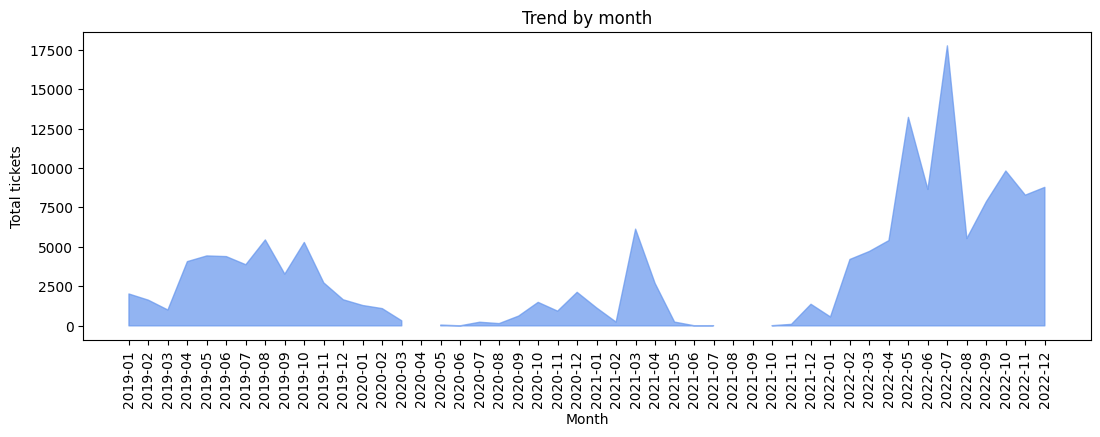

In [ ]:
# Vẽ biểu đồ miền
plt.figure(figsize=(13, 4))
plt.fill_between(df_time_month_dim['year_month'], df_time_month_dim['total_tickets'], alpha=0.7 , color='cornflowerblue')
plt.xticks(rotation=90)
plt.xlabel('Month')
plt.ylabel('Total tickets')
plt.title('Trend by month')
plt.show()

###**Trend by weekdays**

In [ ]:
# Thống kê theo ngày trong tuần
df_time_days = df_join_all.groupby('day_name').agg(
    total_tickets=('ticket_id','count'),
).reset_index()

In [ ]:
df_time_days

,day_name,total_tickets
0,Friday,26438
1,Monday,16702
2,Saturday,34450
3,Sunday,26960
4,Thursday,19101
5,Tuesday,14793
6,Wednesday,16281


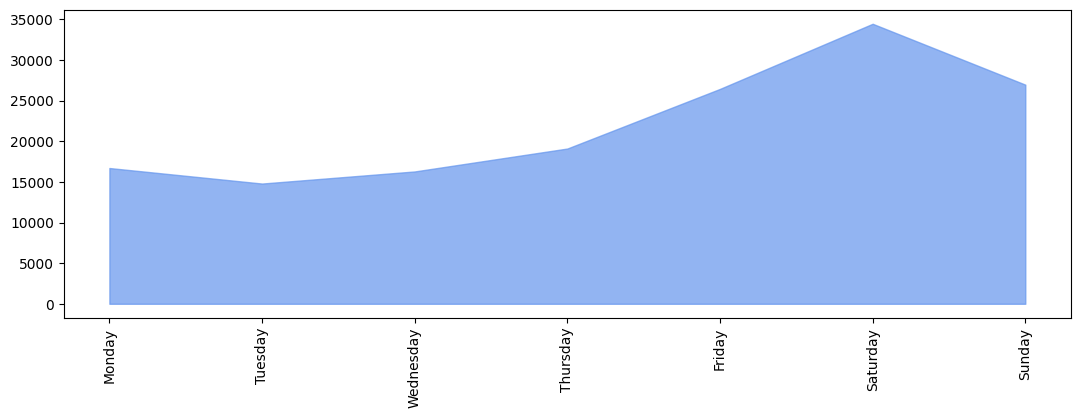

In [ ]:
# Định nghĩa lại thứ tự các ngày trong tuần
week_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
# Sắp xếp theo thứ tự các ngày trong tuần
df_time_days['day_name'] = pd.Categorical(df_time_days['day_name'], categories=week_order, ordered=True)
df_time_days = df_time_days.sort_values('day_name')
# Vẽ biểu đồ miền
plt.figure(figsize=(13, 4))
plt.fill_between(df_time_days['day_name'], df_time_days['total_tickets'], alpha=0.7 , color='cornflowerblue')
plt.xticks(rotation=90)
plt.show()

### **Trend by hours**

In [ ]:
# Thống kê theo giờ
df_time_hours = df_join_all.groupby('hour').agg(
    total_tickets=('ticket_id','count'),
).reset_index()

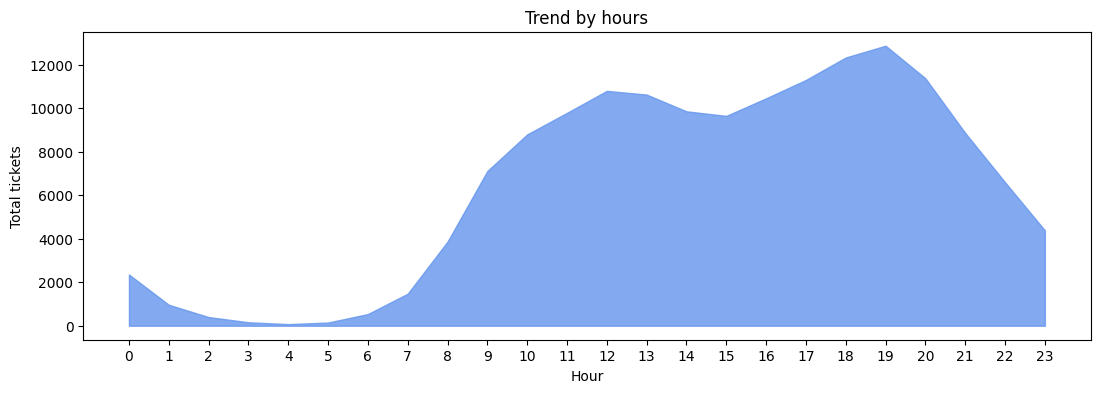

In [ ]:
# Vẽ biểu đồ miền cho hour
plt.figure(figsize=(13, 4))
plt.fill_between(df_time_hours['hour'], df_time_hours['total_tickets'], alpha=0.8 , color='cornflowerblue')
x_values = [i for i in range(24)]
plt.xticks(x_values)
plt.xlabel('Hour')
plt.ylabel('Total tickets')
plt.title('Trend by hours')
plt.show()

##**3.3 Factors related to the customer's purchasing**

###**Payment platform**

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,usergender,dob,model,platform,description,error_group,age_days,age,month,day_name,hour,year_month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,Male,1989-02-25,"iPhone13,1",mobile,Order successful,unknown,13608,37,7,Friday,17,2022-07
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,Male,1991-06-09,browser,website,Order successful,unknown,12774,34,7,Friday,20,2022-07


In [ ]:
df_platform = df_join_all[df_join_all['platform']!='unknown'].groupby('platform').agg(
    total_tickets=('ticket_id','count')
).reset_index()

In [ ]:
df_platform

,platform,total_tickets
0,mobile,138136
1,website,16511


Text(0.5, 1.0, '#ticket by platform')

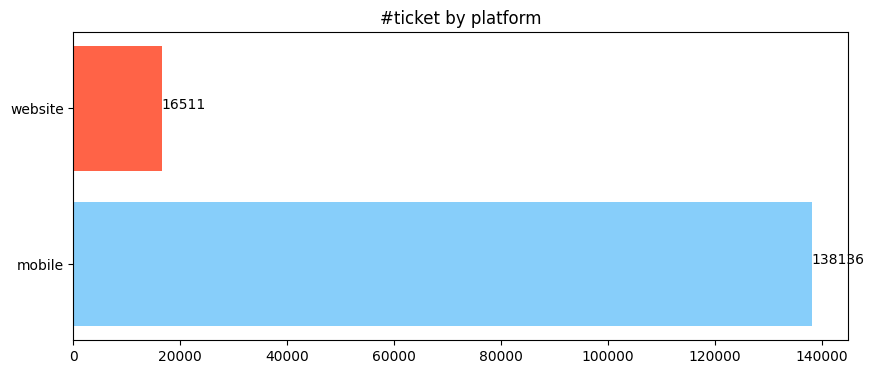

In [ ]:
# Biểu đồ cột ngang
plt.figure(figsize=(10, 4))
plt.barh(
    df_platform['platform'], df_platform['total_tickets'],
    color = df_platform['platform'].replace({ 'mobile': 'lightskyblue',  'website': 'tomato'})
)
for index,value in enumerate(df_platform['total_tickets']):
    plt.text(value,index,str(value))

plt.title('#ticket by platform')

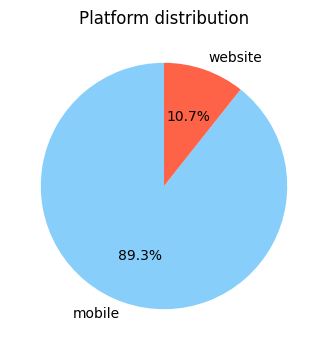

In [ ]:
plt.figure(figsize=(6, 4))
plt.pie(df_platform['total_tickets'], labels=df_platform['platform'], autopct='%1.1f%%', colors=['lightskyblue','tomato'],startangle=90)
plt.title('Platform distribution')
plt.show()

In [ ]:
# Biểu đồ thời gian
df_platform_time = df_join_all[df_join_all['platform']!='unknown'].groupby(['year_month','platform']).agg(
    total_tickets=('ticket_id','count')
).sort_values(by='year_month').reset_index()

In [ ]:
df_platform_time.head(10)

,year_month,platform,total_tickets
0,2019-01,mobile,2019
1,2019-02,mobile,1626
2,2019-03,mobile,1004
3,2019-04,mobile,4069
4,2019-05,mobile,4430
5,2019-06,mobile,4387
6,2019-07,mobile,3872
7,2019-08,mobile,5444
8,2019-09,mobile,3278
9,2019-10,mobile,5284


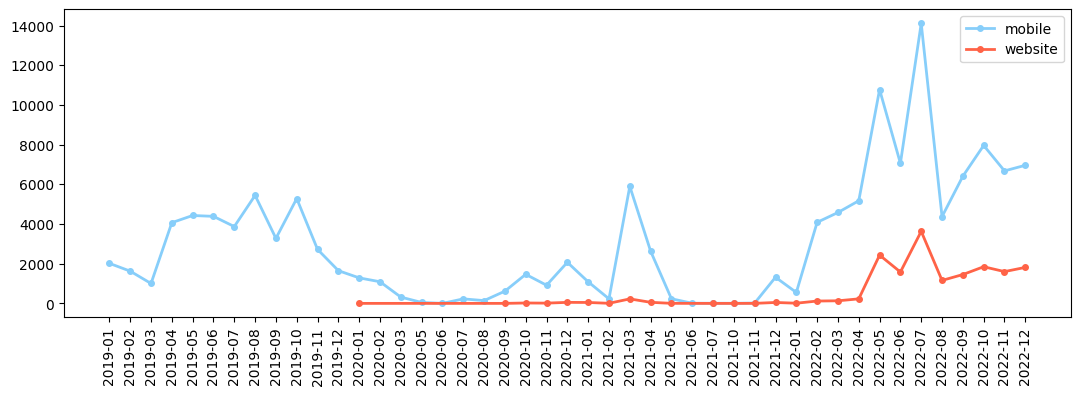

In [ ]:
# vẽ biểu đồ line chart:
plt.figure(figsize=(13, 4))

df_mobile_line = df_platform_time[df_platform_time['platform']=='mobile']
plt.plot(df_mobile_line['year_month'], df_mobile_line['total_tickets'], label='mobile', marker = 'o' ,  color='lightskyblue', linewidth = 2 , markersize = 4)

df_website_line = df_platform_time[df_platform_time['platform']=='website']
plt.plot(df_website_line['year_month'], df_website_line['total_tickets'], label='website', marker = 'o' ,  color='tomato', linewidth = 2 , markersize = 4)

plt.legend()
plt.xticks(rotation=90)
plt.show()

### OS version

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,usergender,dob,model,platform,description,error_group,age_days,age,month,day_name,hour,year_month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,Male,1989-02-25,"iPhone13,1",mobile,Order successful,unknown,13608,37,7,Friday,17,2022-07
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,Male,1991-06-09,browser,website,Order successful,unknown,12774,34,7,Friday,20,2022-07


In [ ]:
# phân loại thiết bị OS thành các nhóm: android, ios, unknown, browser
df_join_all['os_version'] = df_join_all['model'].apply(lambda x: 'ios' if ('iPhone' in x or 'iPod' in x )
                                                        else 'browser' if x == 'browser'
                                                       else 'unknown' if ( 'devicemodel' in x or 'unknown' in x )
                                                       else 'android & other')

In [ ]:
df_join_all['os_version'].unique()

array(['ios', 'browser', 'unknown', 'android & other'], dtype=object)

In [ ]:
# Group by để thống kê
df_os = df_join_all.groupby('os_version').agg(
    total_tickets=('ticket_id','count')).sort_values(by='total_tickets',ascending=True).reset_index()

In [ ]:
df_os

,os_version,total_tickets
0,browser,13377
1,android & other,21092
2,ios,51402
3,unknown,68854


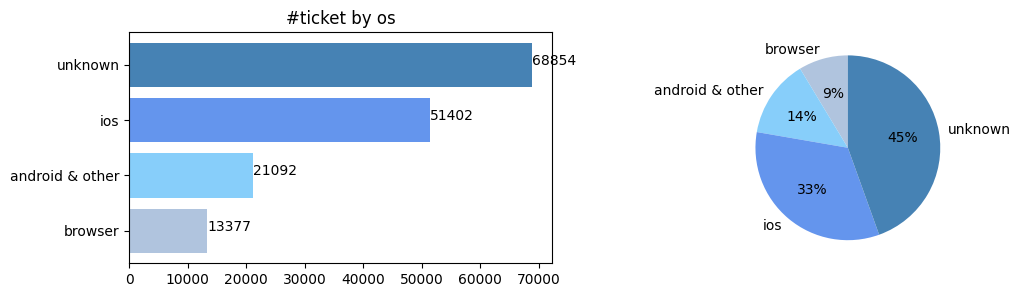

In [ ]:
# Biểu đồ cột ngang :
plt.figure(figsize=(12, 3))

ax1 = plt.subplot(1,2,1)
plt.barh(
    df_os['os_version'], df_os['total_tickets'],
    color = df_os['os_version'].replace({ 'browser': 'lightsteelblue',  'android & other': 'lightskyblue', 'ios': 'cornflowerblue', 'unknown': 'steelblue'})
)

for index,value in enumerate(df_os['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by os')

ax2 = plt.subplot(1,2,2)
plt.pie(df_os['total_tickets'], labels= df_os['os_version'],
        colors=df_os['os_version'].replace({ 'browser': 'lightsteelblue',  'android & other': 'lightskyblue', 'ios': 'cornflowerblue', 'unknown': 'steelblue'}),
        autopct='%1.0f%%',
        startangle=90)
plt.show()

In [ ]:
# Biểu đồ thời gian
df_os_time = df_join_all.groupby(['year_month','os_version']).agg(
    total_tickets=('ticket_id','count')
).sort_values(by='year_month', ascending=True).reset_index()

In [ ]:
df_os_time.head(10)

,year_month,os_version,total_tickets
0,2019-01,android & other,713
1,2019-01,ios,1233
2,2019-01,unknown,73
3,2019-02,android & other,542
4,2019-02,ios,1074
5,2019-02,unknown,10
6,2019-03,android & other,371
7,2019-03,ios,631
8,2019-03,unknown,2
9,2019-04,android & other,1519


In [ ]:
# Xử lí data dạng PIVOT để vẽ biểu đồ miền

df_os_time = (df_join_all.pivot_table(index='year_month', columns='os_version', aggfunc='count', values='ticket_id').reset_index())

In [ ]:
df_os_time.head(10)

os_version,year_month,android & other,browser,ios,unknown
0,2019-01,713.0,NaN,1233.0,73.0
1,2019-02,542.0,NaN,1074.0,10.0
2,2019-03,371.0,NaN,631.0,2.0
3,2019-04,1519.0,NaN,2541.0,9.0
4,2019-05,1601.0,NaN,2826.0,3.0
5,2019-06,1575.0,NaN,2808.0,4.0
6,2019-07,1373.0,NaN,2499.0,NaN
7,2019-08,1797.0,NaN,3642.0,5.0
8,2019-09,1122.0,NaN,2151.0,5.0
9,2019-10,1964.0,NaN,3313.0,7.0


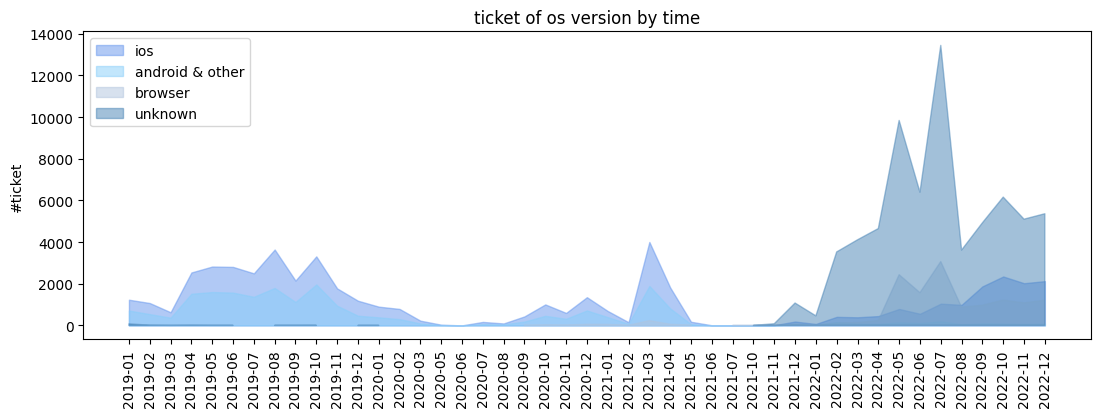

In [ ]:
# vẽ biểu đồ miền theo thời gian

plt.figure(figsize=(13, 4))
plt.fill_between(df_os_time['year_month'], df_os_time['ios'], alpha=0.5 , color='cornflowerblue', label = 'ios')
plt.fill_between(df_os_time['year_month'], df_os_time['android & other'], alpha=0.5 , color='lightskyblue',label = 'android & other')
plt.fill_between(df_os_time['year_month'], df_os_time['browser'], alpha=0.5 , color='lightsteelblue',label = 'browser')
plt.fill_between(df_os_time['year_month'], df_os_time['unknown'], alpha=0.5 , color='steelblue',label = 'unknown')

# hiển thị biểu đồ
plt.title('ticket of os version by time')
#plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc= 'upper left')
plt.xticks(rotation=90)
plt.show()

### Payment method

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,usergender,dob,model,platform,description,error_group,age_days,age,month,day_name,hour,year_month,os_version
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,Male,1989-02-25,"iPhone13,1",mobile,Order successful,unknown,13608,37,7,Friday,17,2022-07,ios
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,Male,1991-06-09,browser,website,Order successful,unknown,12774,34,7,Friday,20,2022-07,browser


In [ ]:
df_method = df_join_all[(df_join_all['status_id'] == 1 ) & (df_join_all['paying_method'] != 'other')].groupby('paying_method').agg(
    total_tickets=('ticket_id','count')
).sort_values(by='total_tickets', ascending=True).reset_index()

In [ ]:
# Xử lí data dạng PIVOT để vẽ biểu đồ miền

df_method_time = (df_join_all[(df_join_all['status_id'] == 1 ) & (df_join_all['paying_method'] != 'other')]
                  .pivot_table(index='year_month', columns='paying_method', aggfunc='count', values='ticket_id')
                  .reset_index())

In [ ]:
df_method_time.head(10)

paying_method,year_month,bank account,credit card,debit card,money in app
0,2019-01,487.0,336.0,93.0,443.0
1,2019-02,484.0,370.0,93.0,480.0
2,2019-03,304.0,225.0,74.0,263.0
3,2019-04,1050.0,705.0,189.0,1246.0
4,2019-05,1092.0,903.0,212.0,1410.0
5,2019-06,1074.0,962.0,249.0,1319.0
6,2019-07,916.0,782.0,252.0,1215.0
7,2019-08,1367.0,1142.0,321.0,1684.0
8,2019-09,774.0,711.0,219.0,1068.0
9,2019-10,1280.0,914.0,309.0,1833.0


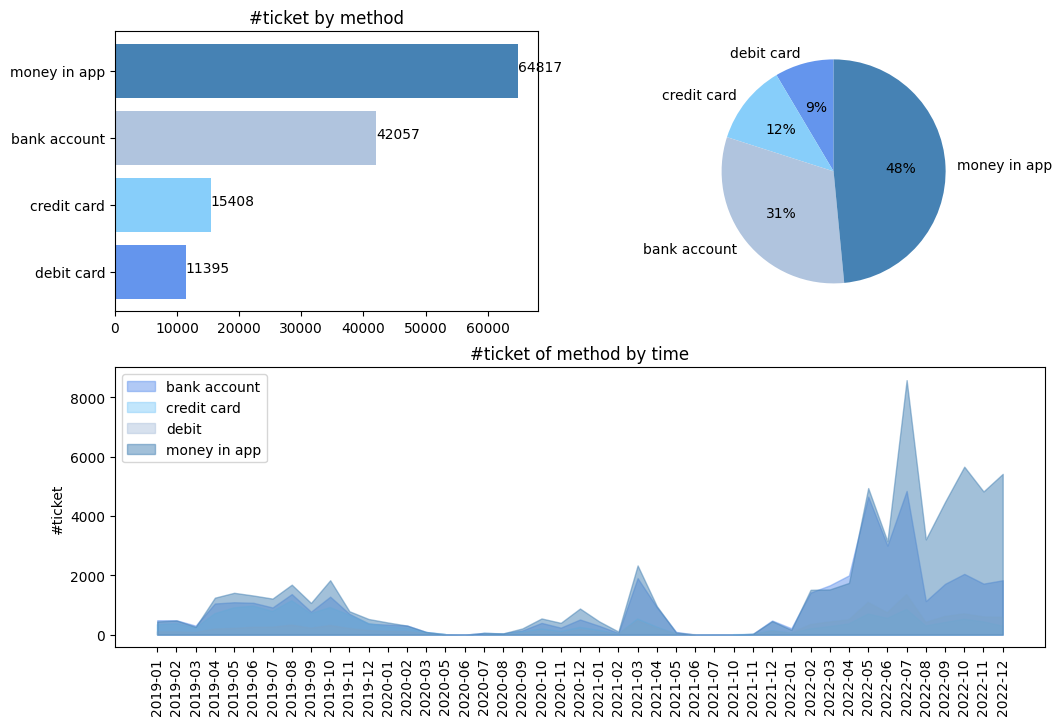

In [ ]:
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(2,2,1)
plt.barh(
    df_method['paying_method'], df_method['total_tickets'],
    color = df_method['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'})
)

for index,value in enumerate(df_method['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by method')

ax2 = plt.subplot(2,2,2)
plt.pie(df_method['total_tickets'], labels= df_method['paying_method'],
        colors=df_method['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'}),
        autopct='%1.0f%%',
        startangle=90)

ax3 = plt.subplot(2,1,2)
plt.fill_between(df_method_time['year_month'], df_method_time['bank account'], color='cornflowerblue', alpha=0.5, label='bank account')
plt.fill_between(df_method_time['year_month'], df_method_time['credit card'], color='lightskyblue', alpha=0.5, label='credit card')
plt.fill_between(df_method_time['year_month'], df_method_time['debit card'], color='lightsteelblue', alpha=0.5, label='debit')
plt.fill_between(df_method_time['year_month'], df_method_time['money in app'], color='steelblue', alpha=0.5, label='money in app')

plt.title('#ticket of method by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper left')
plt.xticks(rotation=90)
plt.show()


In [ ]:
# biểu đồ miền 100%
df_method_time = (df_join_all[(df_join_all['status_id'] == 1 ) & (df_join_all['paying_method'] != 'other')]
                  .pivot_table(index='year_month', columns='paying_method', aggfunc='count', values='ticket_id')
                  .reset_index())

df_method_time_pct = df_method_time.copy()
df_method_time_pct = df_method_time_pct.fillna(0)

df_method_time_pct['total'] = df_method_time_pct.iloc[:,1:].sum(axis=1)

for i in df_method_time_pct.columns[1:5]:
    df_method_time_pct[i+'_pct'] = df_method_time_pct[i] / df_method_time_pct['total']

df_method_time_pct.head(10)

paying_method,year_month,bank account,credit card,debit card,money in app,total,bank account_pct,credit card_pct,debit card_pct,money in app_pct
0,2019-01,487.0,336.0,93.0,443.0,1359.0,0.358352,0.247241,0.068433,0.325975
1,2019-02,484.0,370.0,93.0,480.0,1427.0,0.339173,0.259285,0.065172,0.336370
2,2019-03,304.0,225.0,74.0,263.0,866.0,0.351039,0.259815,0.085450,0.303695
3,2019-04,1050.0,705.0,189.0,1246.0,3190.0,0.329154,0.221003,0.059248,0.390596
4,2019-05,1092.0,903.0,212.0,1410.0,3617.0,0.301908,0.249654,0.058612,0.389826
5,2019-06,1074.0,962.0,249.0,1319.0,3604.0,0.298002,0.266926,0.069090,0.365982
6,2019-07,916.0,782.0,252.0,1215.0,3165.0,0.289415,0.247077,0.079621,0.383886
7,2019-08,1367.0,1142.0,321.0,1684.0,4514.0,0.302836,0.252991,0.071112,0.373062
8,2019-09,774.0,711.0,219.0,1068.0,2772.0,0.279221,0.256494,0.079004,0.385281
9,2019-10,1280.0,914.0,309.0,1833.0,4336.0,0.295203,0.210793,0.071264,0.422740


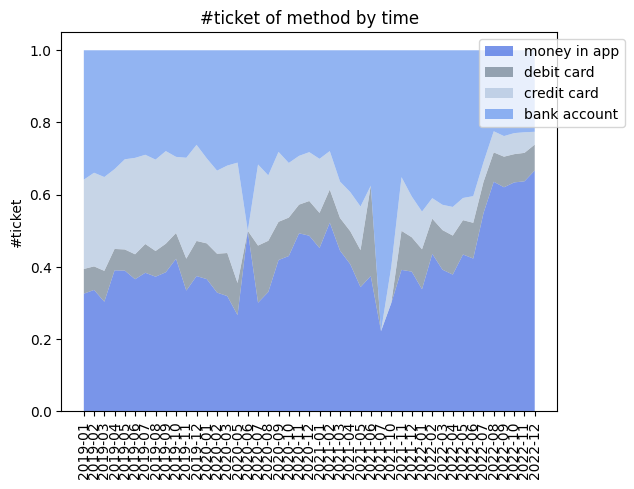

In [ ]:
# vẽ biểu đồ miền 100%
plt.stackplot(df_method_time_pct['year_month'], df_method_time_pct["money in app_pct"],  df_method_time_pct['debit card_pct'], df_method_time_pct['credit card_pct'], df_method_time_pct['bank account_pct']
              , labels=['money in app', 'debit card', 'credit card', 'bank account'], colors=['royalblue', 'slategrey', 'lightsteelblue', 'cornflowerblue'], alpha=0.7)

plt.title('#ticket of method by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=90)

plt.subplots_adjust(hspace = 0.7, top = 0.9)

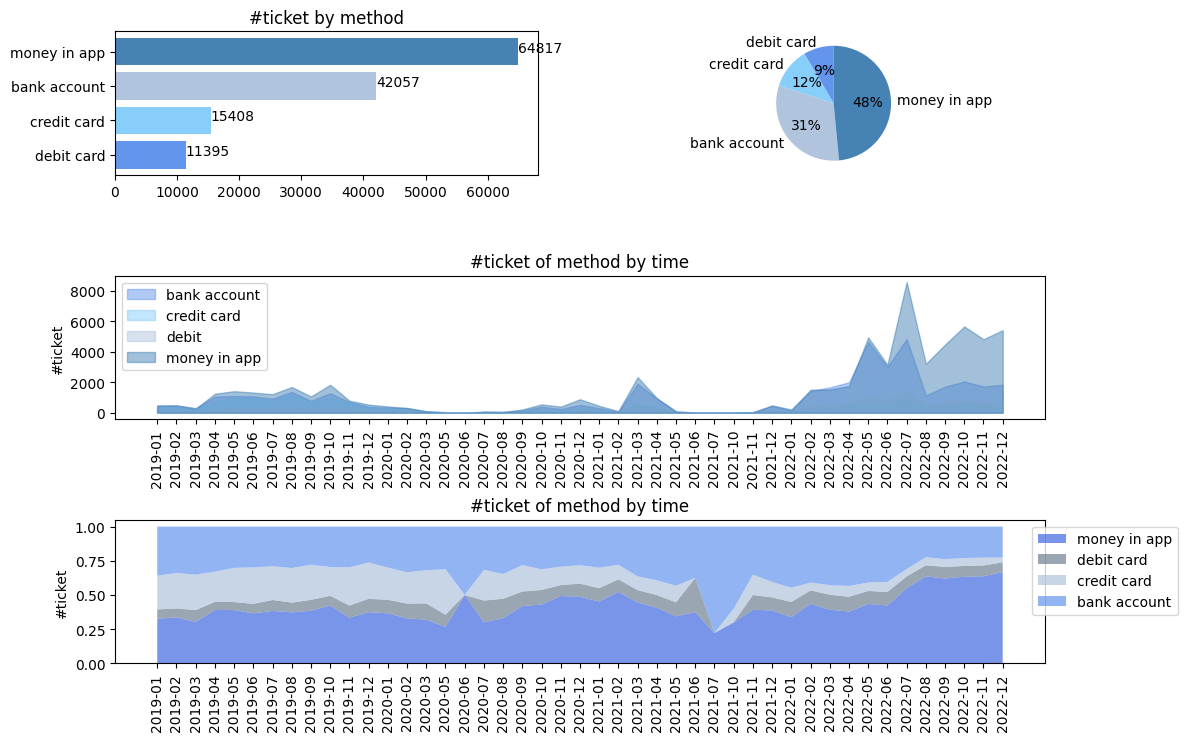

In [ ]:
# biểu diễn chung 1 frame
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(3,2,1)
plt.barh(
    df_method['paying_method'], df_method['total_tickets'],
    color = df_method['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'})
)

for index,value in enumerate(df_method['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by method')

ax2 = plt.subplot(3,2,2)
plt.pie(df_method['total_tickets'], labels= df_method['paying_method'],
        colors=df_method['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'}),
        autopct='%1.0f%%',
        startangle=90)

ax3 = plt.subplot(3,1,2)
plt.fill_between(df_method_time['year_month'], df_method_time['bank account'], color='cornflowerblue', alpha=0.5, label='bank account')
plt.fill_between(df_method_time['year_month'], df_method_time['credit card'], color='lightskyblue', alpha=0.5, label='credit card')
plt.fill_between(df_method_time['year_month'], df_method_time['debit card'], color='lightsteelblue', alpha=0.5, label='debit')
plt.fill_between(df_method_time['year_month'], df_method_time['money in app'], color='steelblue', alpha=0.5, label='money in app')

plt.title('#ticket of method by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper left')
plt.xticks(rotation=90)

ax4 = plt.subplot(3,1,3)
# vẽ biểu đồ miền 100%
plt.stackplot(df_method_time_pct['year_month'], df_method_time_pct["money in app_pct"],  df_method_time_pct['debit card_pct'], df_method_time_pct['credit card_pct'], df_method_time_pct['bank account_pct']
              , labels=['money in app', 'debit card', 'credit card', 'bank account'], colors=['royalblue', 'slategrey', 'lightsteelblue', 'cornflowerblue'], alpha=0.7)

plt.title('#ticket of method by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=90)

plt.subplots_adjust(hspace = 0.7, top = 0.9)

### Promotion

In [ ]:
df_join_all['campaign_type'].unique()

array(['direct discount', 'unknown', 'voucher', 'reward point'],
      dtype=object)

In [ ]:
df_join_all['type'] = df_join_all['campaign_type'].apply(lambda x: 'non-promotion' if x == 'unknown' else 'promotion')

In [ ]:
df_type = df_join_all[(df_join_all['status_id'] == 1 ) & (df_join_all['paying_method'] != 'other')].groupby('type').agg(
    total_tickets=('ticket_id','count')
).sort_values(by='total_tickets', ascending=True).reset_index()

In [ ]:
df_type

,type,total_tickets
0,non-promotion,55155
1,promotion,78522


In [ ]:
# Xử lí data dạng PIVOT để vẽ biểu đồ miền

df_type_time = (df_join_all[(df_join_all['status_id'] == 1 ) & (df_join_all['paying_method'] != 'other')]
                  .pivot_table(index='year_month', columns='type', aggfunc='count', values='ticket_id')
                  .reset_index())

df_type_time_pct = df_type_time.copy()
df_type_time_pct = df_type_time_pct.fillna(0)

df_type_time_pct['total'] = df_type_time_pct.iloc[:,1:].sum(axis=1)

for i in df_type_time_pct.columns[1:3]:
    df_type_time_pct[i+'_pct'] = df_type_time_pct[i] / df_type_time_pct['total']

df_type_time_pct.head(10)

type,year_month,non-promotion,promotion,total,non-promotion_pct,promotion_pct
0,2019-01,517.0,842.0,1359.0,0.380427,0.619573
1,2019-02,1335.0,92.0,1427.0,0.935529,0.064471
2,2019-03,835.0,31.0,866.0,0.964203,0.035797
3,2019-04,1699.0,1491.0,3190.0,0.532602,0.467398
4,2019-05,1564.0,2053.0,3617.0,0.432403,0.567597
5,2019-06,1391.0,2213.0,3604.0,0.385960,0.614040
6,2019-07,1364.0,1801.0,3165.0,0.430964,0.569036
7,2019-08,1556.0,2958.0,4514.0,0.344705,0.655295
8,2019-09,922.0,1850.0,2772.0,0.332612,0.667388
9,2019-10,1354.0,2982.0,4336.0,0.312269,0.687731


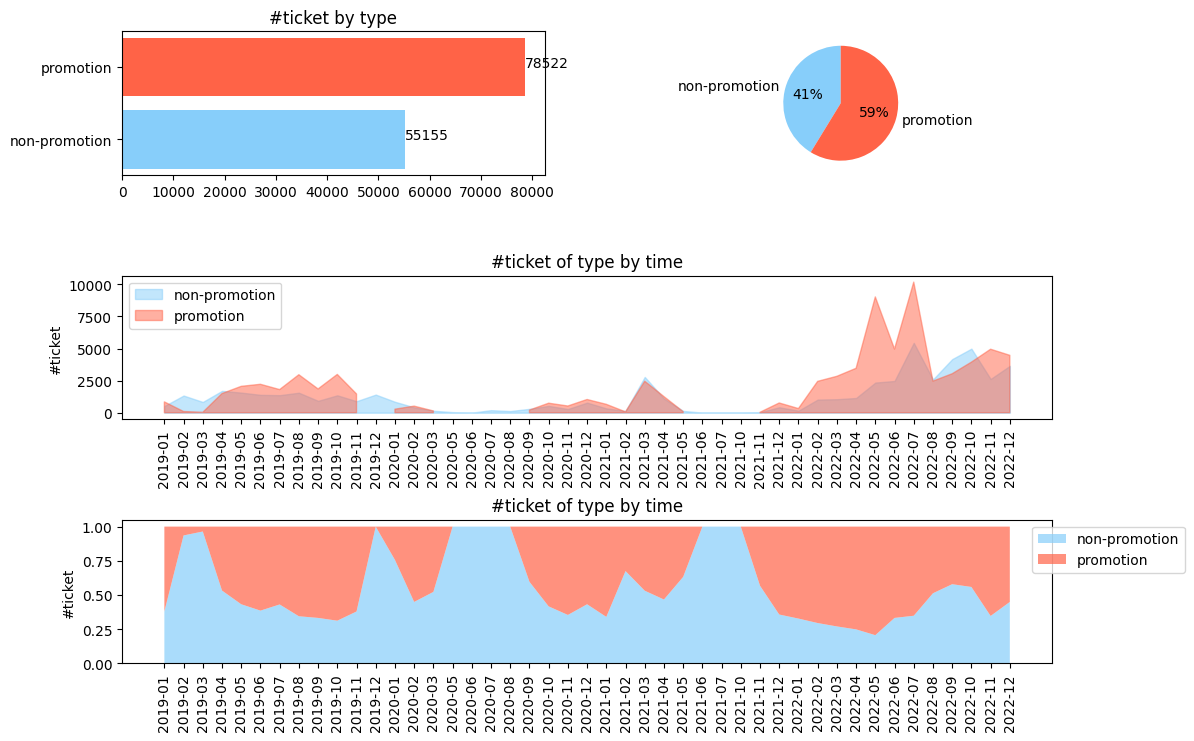

In [ ]:
# biểu diễn chung 1 frame
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(3,2,1)
plt.barh(
    df_type['type'], df_type['total_tickets'],
    color = df_type['type'].replace({ 'non-promotion': 'lightskyblue',  'promotion': 'tomato'})
)

for index,value in enumerate(df_type['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by type')

ax2 = plt.subplot(3,2,2)
plt.pie(df_type['total_tickets'], labels= df_type['type'],
        colors=df_type['type'].replace({'non-promotion': 'lightskyblue', 'promotion': 'tomato'}),
        autopct='%1.0f%%',
        startangle=90)

ax3 = plt.subplot(3,1,2)
plt.fill_between(df_type_time['year_month'], df_type_time['non-promotion'], color='lightskyblue', alpha=0.5, label='non-promotion')
plt.fill_between(df_type_time['year_month'], df_type_time['promotion'], color='tomato', alpha=0.5, label='promotion')

plt.title('#ticket of type by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper left')
plt.xticks(rotation=90)

ax4 = plt.subplot(3,1,3)
# vẽ biểu đồ miền 100%
plt.stackplot(df_type_time_pct['year_month'], df_type_time_pct["non-promotion_pct"],  df_type_time_pct['promotion_pct']
              , labels=['non-promotion','promotion'], colors=['lightskyblue', 'tomato'], alpha=0.7)

plt.title('#ticket of type by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=90)

plt.subplots_adjust(hspace = 0.7, top = 0.9)

### Which movies they watched?

In [ ]:
df_film_sum = (
    df_join_all[df_join_all['status_id'] ==1]
    .groupby('movie_name')
    .agg(
        total_tickets=('ticket_id','count'),
        total_customer=('customer_id','nunique'),
        revenue=('final_price','sum')
    )
    .sort_values(by='total_tickets', ascending=False)
    .reset_index()
)

In [ ]:
df_film_sum.head(10)

,movie_name,total_tickets,total_customer,revenue
0,Doctor Strange In The Multiverse Of Madness,8615,8409,65579.98
1,Minions: The Rise Of Gru,7224,7014,56530.93
2,Avatar: The Way Of Water,5870,5612,59830.95
3,Thor: Love And Thunder,5589,5478,43372.90
4,Peninsula,5499,5365,41208.44
5,Black Panther 2: Wakanda Forever,3847,3790,26860.28
6,Black Adam,3229,3186,23159.34
7,Avengers: Endgame,3219,3135,26690.48
8,Dad I'm Sorry,3023,2817,25863.28
9,Love Destiny,2411,2376,18345.61


In [ ]:
list_film = df_film_sum[df_film_sum['total_tickets'] > 1000 ]['movie_name'].unique()
list_selected_film = list(list_film)

In [ ]:
list_selected_film

['Doctor Strange In The Multiverse Of Madness',
 'Minions: The Rise Of Gru',
 'Avatar: The Way Of Water',
 'Thor: Love And Thunder',
 'Peninsula',
 'Black Panther 2: Wakanda Forever',
 'Black Adam',
 'Avengers: Endgame',
 "Dad I'm Sorry",
 'Love Destiny',
 'You And Trinh',
 'Fast & Furious Presents: Hobbs & Shaw',
 'Emergency Declaration',
 'Jurassic World Dominion',
 'Godzilla Vs. Kong',
 'Detective Conan: The Bride Of Halloween',
 'Joker',
 'Spider-Man: No Way Home',
 'Batman',
 'Blood Moon Party',
 'Fantastic Beasts: Secrets Of Dumbledore',
 'Top Gun: Maverick',
 'Naked Truth',
 "Doraemon: Nobita's Little Star Wars 2021",
 'One Piece Film: Red',
 'Confidential Assignment 2: International',
 'Extremely Easy Job',
 'Morbius',
 'Spider-Man Far From Home',
 'Maleficent',
 'Face Off: 48h',
 'Parasite']

In [ ]:
# Xử lí data dạng PIVOT

df_movie_time_pivot = (df_join_all[(df_join_all['status_id'] == 1 ) & (df_join_all['movie_name'].isin(list_selected_film))]
                  .pivot_table(index='year_month', columns='movie_name', aggfunc='count', values='ticket_id')
                  .reset_index())

In [ ]:
df_movie_time_pivot.head(10)

movie_name,year_month,Avatar: The Way Of Water,Avengers: Endgame,Batman,Black Adam,Black Panther 2: Wakanda Forever,Blood Moon Party,Confidential Assignment 2: International,Dad I'm Sorry,Detective Conan: The Bride Of Halloween,Doctor Strange In The Multiverse Of Madness,Doraemon: Nobita's Little Star Wars 2021,Emergency Declaration,Extremely Easy Job,Face Off: 48h,Fantastic Beasts: Secrets Of Dumbledore,Fast & Furious Presents: Hobbs & Shaw,Godzilla Vs. Kong,Joker,Jurassic World Dominion,Love Destiny,Maleficent,Minions: The Rise Of Gru,Morbius,Naked Truth,One Piece Film: Red,Parasite,Peninsula,Spider-Man Far From Home,Spider-Man: No Way Home,Thor: Love And Thunder,Top Gun: Maverick,You And Trinh
0,2019-04,NaN,2081.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-05,NaN,1130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-06,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,751.0,NaN,28.0,NaN,NaN,NaN,NaN
3,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,286.0,NaN,1125.0,NaN,NaN,NaN,NaN
4,2019-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2019-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1405.0,NaN,NaN,1008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2019-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2020-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN
9,2020-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN


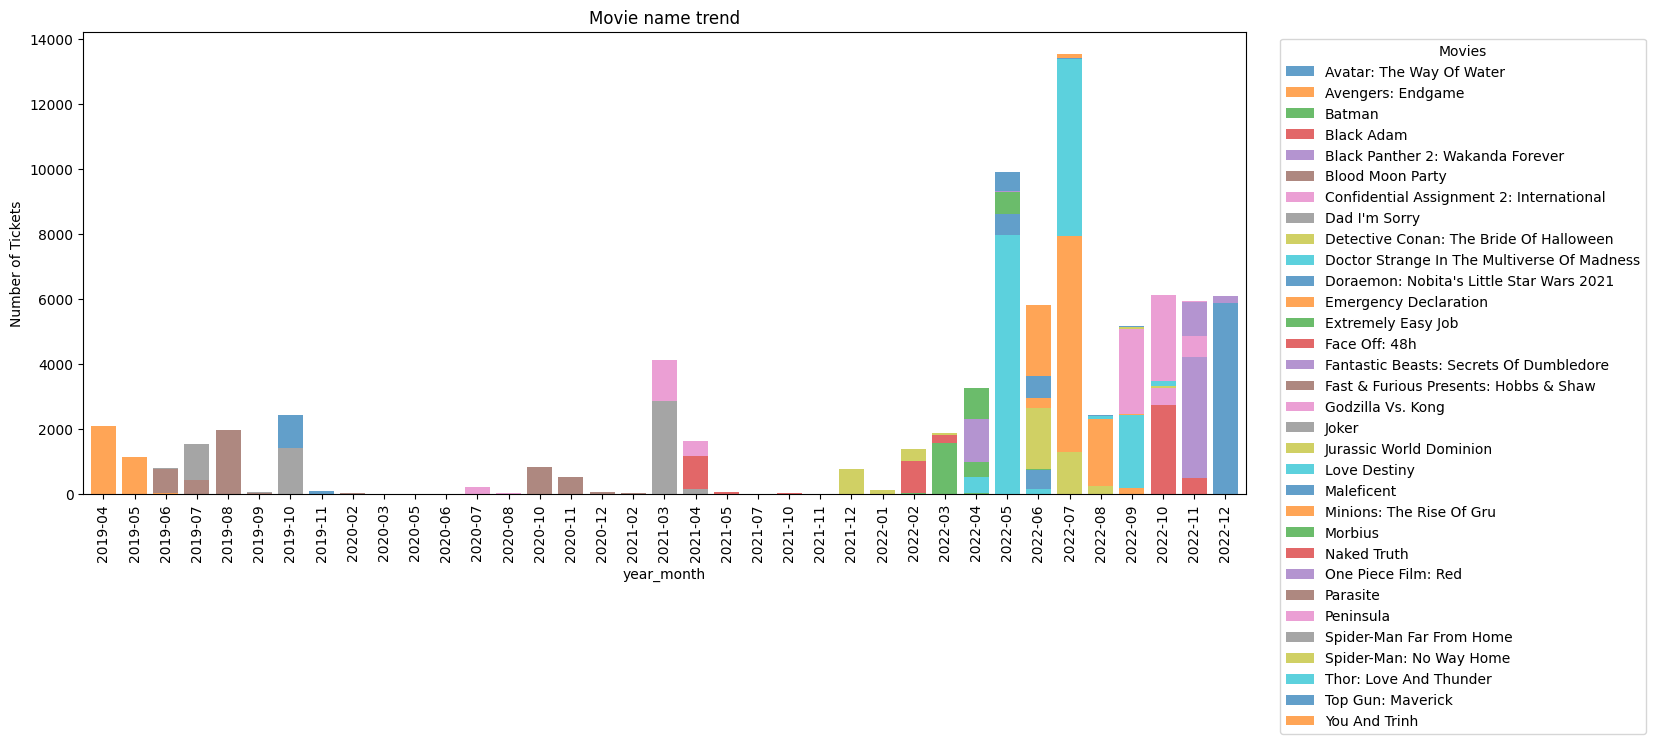

In [ ]:
#Biểu đồ cột chồng
ax = df_movie_time_pivot.plot(x = 'year_month', kind='bar', stacked=True, figsize=(15, 6), width=0.8, alpha = 0.7)

# Set the title and labels
ax.set_title('Movie name trend')
# ax.set_xlabel('Month')
ax.set_ylabel('Number of Tickets')

# Add a legend
plt.legend(title='Movies', loc='upper right', bbox_to_anchor=(1.35, 1))

# Show the plot
plt.show()

## 3.4 Customer value dimension


  Mục tiêu: Phân tích các chỉ số về giá trị mà 1 khách hàng mang lại

*   Frequency: count,day,month
*   Monetary: total_money, total_discount
*   Success rate = number / total
*   Promotion_rate = number_promotion / total_success
*   Discount_rate = sum_discount / sum_money

























In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,usergender,dob,model,platform,description,error_group,age_days,age,month,day_name,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,Male,1989-02-25,"iPhone13,1",mobile,Order successful,unknown,13608,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,Male,1991-06-09,browser,website,Order successful,unknown,12774,34,7,Friday,20,2022-07,browser,promotion


In [ ]:
# Tính các chỉ số cho những vé giao dịch thành công
def calculate_n_promotion(x):
  return (x=='promotion').sum()

df_success_metric = (
    df_join_all[df_join_all['status_id'] ==1]
    .assign( date= pd.to_datetime(df_join_all['time']).dt.date)
    .groupby('customer_id')
    .agg(
        n_success=('ticket_id','count'),
        s_money=('original_price','sum'),
        s_discount=('discount_value','sum'),
        n_days=('date','nunique'),
        n_months=('year_month','nunique'),
        n_promotions=('type',calculate_n_promotion)
        ).reset_index()
    )

In [ ]:
# Tính các chỉ số: total và số giao dịch lỗi:

def calculate_n_failed(x):
  return (x!=1).sum()

df_failed_metric = (
    df_join_all
    .groupby('customer_id')
    .agg(
        n_total = ('ticket_id','count'),
        n_failed = ('status_id',calculate_n_failed)
         ).reset_index()
    )

In [ ]:
# join 2 bảng

df_customer_value = pd.merge(df_failed_metric, df_success_metric, on='customer_id', how='left').fillna(0)

In [ ]:
df_customer_value['success_rate'] = df_customer_value['n_success'] / df_customer_value['n_total']
df_customer_value['promotion_rate'] = df_customer_value['n_promotions'] / df_customer_value['n_success']
df_customer_value['discount_rate'] = df_customer_value['s_discount'] / df_customer_value['s_money']

In [ ]:
df_customer_value.head(5)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_days,n_months,n_promotions,success_rate,promotion_rate,discount_rate
0,100001,1,0,1.0,7.42,2.06,1.0,1.0,1.0,1.0,1.000000,0.277628
1,100003,6,0,6.0,60.95,2.56,6.0,6.0,1.0,1.0,0.166667,0.042002
2,100004,1,0,1.0,32.25,0.00,1.0,1.0,0.0,1.0,0.000000,0.000000
3,100005,1,0,1.0,9.49,2.06,1.0,1.0,1.0,1.0,1.000000,0.217071
4,100006,1,0,1.0,12.37,0.00,1.0,1.0,0.0,1.0,0.000000,0.000000


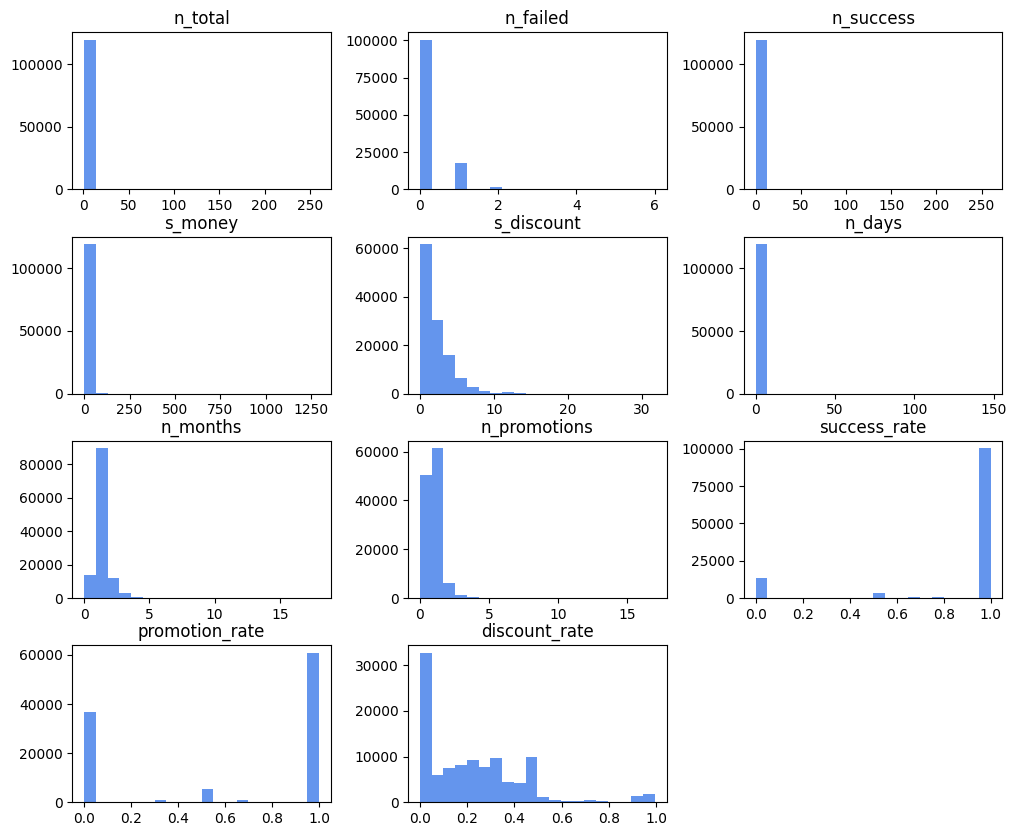

In [ ]:
# Visualize tất cả các chỉ số bằng Histogram

df_customer_value.iloc[:,1:].hist(figsize=(12,10), grid = False , color='cornflowerblue', bins = 20)
plt.show()

>- **Notes:**
>>- **n_total**: Hầu hết khách hàng mua vé rất ít, nhưng có những người mua rất nhiều --> check những người này.
>>- **success rate**: Có khoảng ~10% giao dịch SR = 0%
>>- **promotion**: Có hơn 60k khách hàng chỉ tham gia promotion khi rate = 100%

### Frequency & anomaly behavior

In [ ]:
df_customer_value['n_order_dis'] = df_customer_value['n_success'].apply(lambda x: 'more than 10' if x >= 10 else str(x))

In [ ]:
df_customer_value.head(2)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_days,n_months,n_promotions,success_rate,promotion_rate,discount_rate,n_order_dis
0,100001,1,0,1.0,7.42,2.06,1.0,1.0,1.0,1.0,1.000000,0.277628,1.0
1,100003,6,0,6.0,60.95,2.56,6.0,6.0,1.0,1.0,0.166667,0.042002,6.0


In [ ]:
df_n_dis = df_customer_value.groupby('n_order_dis').agg(
    total_cus=('customer_id','count')).reset_index()

In [ ]:
df_n_dis.head(2)

,n_order_dis,total_cus
0,0.0,13701
1,1.0,87921


Text(0.5, 1.0, '#customer of each group')

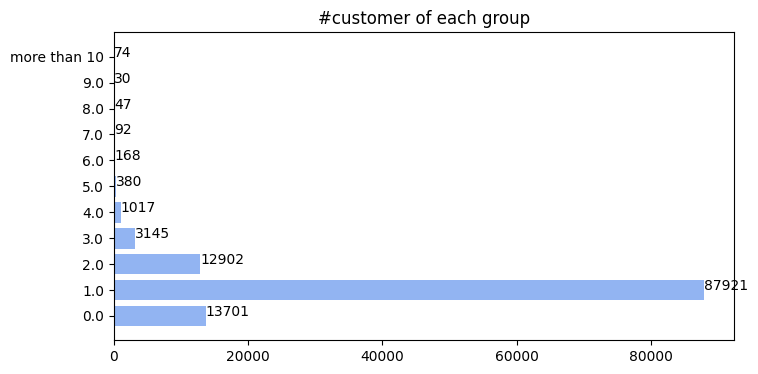

In [ ]:
# Biểu đồ cột ngang
plt.figure(figsize=(8, 4))
plt.barh(
    df_n_dis['n_order_dis'], df_n_dis['total_cus'],
    color = 'cornflowerblue',alpha= 0.7
)

for index,value in enumerate(df_n_dis['total_cus']):
    plt.text(value,index,str(value))
plt.title('#customer of each group')


In [ ]:
# Nếu họ mua dồn vào 1 lúc --> bất thường
# Nếu họ mua dàn trải --> bình thường

In [ ]:
df_customer_value.sort_values(by='n_success', ascending=False).head(20)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_days,n_months,n_promotions,success_rate,promotion_rate,discount_rate,n_order_dis
2686,102948,260,0,260.0,1291.25,3.38,148.0,18.0,1.0,1.000000,0.003846,0.002618,more than 10
48948,153588,108,1,107.0,434.59,0.00,77.0,14.0,0.0,0.990741,0.000000,0.000000,more than 10
10604,111644,104,0,104.0,581.70,18.52,85.0,18.0,9.0,1.000000,0.086538,0.031838,more than 10
15783,117362,104,1,103.0,744.86,8.62,79.0,15.0,6.0,0.990385,0.058252,0.011573,more than 10
16687,118349,83,3,80.0,344.56,4.21,62.0,17.0,1.0,0.963855,0.012500,0.012218,more than 10
20907,122962,77,1,76.0,447.00,1.86,45.0,9.0,3.0,0.987013,0.039474,0.004161,more than 10
72718,179471,69,1,68.0,375.91,7.14,51.0,9.0,4.0,0.985507,0.058824,0.018994,more than 10
62432,168132,69,3,66.0,249.03,0.00,59.0,14.0,0.0,0.956522,0.000000,0.000000,more than 10
111563,222641,51,0,51.0,240.84,2.31,41.0,11.0,3.0,1.000000,0.058824,0.009591,more than 10
53097,158089,53,2,51.0,245.14,1.69,40.0,14.0,2.0,0.962264,0.039216,0.006894,more than 10


In [ ]:
list_customer_massive = list(df_customer_value[df_customer_value['n_success'] > 30 ]['customer_id'].unique())

In [ ]:
list_customer_massive

[np.int64(102948),
 np.int64(103035),
 np.int64(103347),
 np.int64(108110),
 np.int64(108162),
 np.int64(108729),
 np.int64(111644),
 np.int64(114205),
 np.int64(117140),
 np.int64(117362),
 np.int64(117475),
 np.int64(118349),
 np.int64(122962),
 np.int64(131905),
 np.int64(153124),
 np.int64(153588),
 np.int64(158089),
 np.int64(168132),
 np.int64(179471),
 np.int64(222641),
 np.int64(226527),
 np.int64(226886)]

In [ ]:
df_customer_massive_pivot = (
    df_join_all[(df_join_all['customer_id'].isin(list_customer_massive)) & (df_join_all['status_id'] == 1)]
    .pivot_table(index='year_month', columns='customer_id', aggfunc='count', values='ticket_id')
    .reset_index()
)

In [ ]:
df_customer_massive_pivot.head(10)

customer_id,year_month,102948,103035,103347,108110,108162,108729,111644,114205,117140,117362,117475,118349,122962,131905,153124,153588,158089,168132,179471,222641,226527,226886
0,2019-01,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-04,NaN,3.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN
4,2019-05,NaN,2.0,NaN,NaN,4.0,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,2.0,3.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN
5,2019-06,NaN,NaN,NaN,NaN,2.0,NaN,NaN,2.0,1.0,NaN,1.0,NaN,NaN,1.0,7.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN
6,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN
7,2019-08,NaN,3.0,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
8,2019-09,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN
9,2019-10,NaN,4.0,NaN,NaN,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN


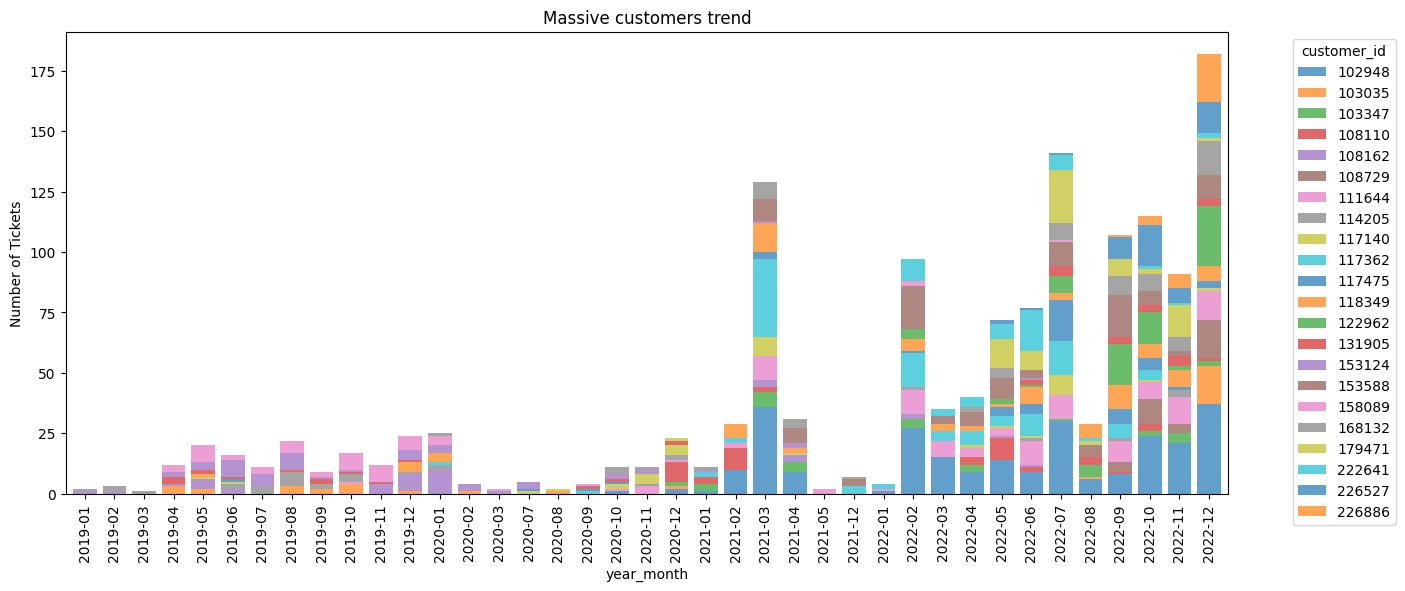

In [ ]:
#Biểu đồ cột chồng
ax = df_customer_massive_pivot.plot(x = 'year_month', kind='bar', stacked=True, figsize=(15, 6), width=0.8, alpha = 0.7)

# Set the title and labels
ax.set_title('Massive customers trend')
# ax.set_xlabel('Month')
ax.set_ylabel('Number of Tickets')

# Add a legend
plt.legend(title='customer_id', loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the plot
plt.show()

>- **Notes:**
>>- Nhóm khách hàng mua vé > 30 lượt phân bố dàn trải --> không có hiện tượng spam vé, mua đi bán lại.
>>- Chưa có gì bất thường.

### Massive promotion

In [ ]:
df_customer_value['n_promo_dis'] = df_customer_value['n_promotions'].apply(lambda x: 'more than 10' if x >= 10 else str(x))

In [ ]:
df_promo_dis = df_customer_value.groupby('n_promo_dis').agg(
    total_cus=('customer_id','count')).reset_index()

In [ ]:
df_promo_dis.head(10)

,n_promo_dis,total_cus
0,0.0,50498
1,1.0,61334
2,2.0,6264
3,3.0,1042
4,4.0,230
5,5.0,74
6,6.0,19
7,7.0,10
8,8.0,2
9,9.0,2


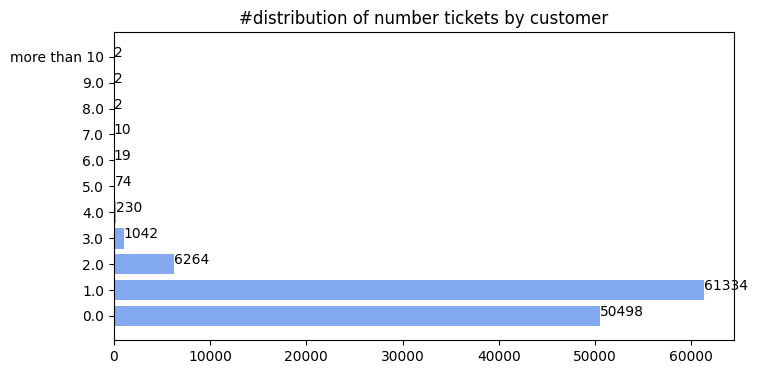

In [ ]:
# Biểu đồ cột ngang
plt.figure(figsize=(8, 4))

plt.barh(
    df_promo_dis['n_promo_dis'], df_promo_dis['total_cus'],
    color = 'cornflowerblue',alpha= 0.8
)

for index,value in enumerate(df_promo_dis['total_cus']):
    plt.text(value,index,str(value))

plt.title('#distribution of number tickets by customer')
plt.show()

>>- ~60% KH là có join vào các chương trình khuyến mãi
>>- Trong đó 90% là chỉ hưởng khuyến mãi 1 lần duy nhất
>>>- 1. Khách hàng đến 1 lần rồi thôi
>>>- 2. Các chương trình chỉ cho 1 người dùng 1 lần (danh cho new customers)??? --> verify với các team Product hoặc Marketing

In [ ]:
# Vậy loại khuyến mãi khách hàng đang dùng là gì ?

In [ ]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,usergender,dob,model,platform,description,error_group,age_days,age,month,day_name,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,Male,1989-02-25,"iPhone13,1",mobile,Order successful,unknown,13608,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,Male,1991-06-09,browser,website,Order successful,unknown,12774,34,7,Friday,20,2022-07,browser,promotion


In [ ]:
# Đánh giá loại khuyến mãi mà khách hàng dùng:
df_type_group = (
    df_join_all[(df_join_all['status_id'] ==1) &  (df_join_all['type'] == 'promotion')]
    .groupby(['campaign_type'])
    .agg(
        total=('ticket_id','count')
    )
    .reset_index()
)

In [ ]:
df_type_group

,campaign_type,total
0,direct discount,68449
1,reward point,3150
2,voucher,6924


In [ ]:
# Tính tỉ lệ loại khuyến mãi chi tiết cho từng nhóm khách hàng


In [ ]:
df_n_success = (
    df_join_all[(df_join_all['status_id'] ==1) &  (df_join_all['type'] == 'promotion')]
    .groupby('customer_id')
    .agg(
        n_promotions=('ticket_id','count')
))

In [ ]:
df_n_pivot = (df_join_all[(df_join_all['status_id'] == 1 ) & (df_join_all['type'] == 'promotion')]
                  .pivot_table(index='customer_id', columns='campaign_type', aggfunc='count', values='ticket_id')
                  .reset_index())

In [ ]:
df_n_pivot.head(10)

campaign_type,customer_id,direct discount,reward point,voucher
0,100001,NaN,NaN,1.0
1,100003,1.0,NaN,NaN
2,100005,NaN,NaN,1.0
3,100007,1.0,NaN,NaN
4,100009,7.0,NaN,NaN
5,100010,1.0,NaN,NaN
6,100014,2.0,NaN,NaN
7,100015,NaN,NaN,2.0
8,100018,1.0,NaN,NaN
9,100020,1.0,NaN,NaN


In [ ]:
df_n_join = (
    pd.merge(df_n_pivot, df_n_success, on='customer_id', how='inner')
    .groupby('n_promotions').agg(
         n_cus = ('customer_id','count'),
         n_voucher = ('voucher','sum'),
         n_d_discount = ('direct discount','sum'),
         n_reward_point = ('reward point','sum')
         ).reset_index()
)

In [ ]:
df_n_join.head(10)

,n_promotions,n_cus,n_voucher,n_d_discount,n_reward_point
0,1,61334,5358.0,53098.0,2878.0
1,2,6264,1091.0,11222.0,215.0
2,3,1042,293.0,2788.0,45.0
3,4,230,87.0,827.0,6.0
4,5,74,43.0,323.0,4.0
5,6,19,12.0,102.0,0.0
6,7,10,14.0,54.0,2.0
7,8,2,2.0,14.0,0.0
8,9,2,6.0,12.0,0.0
9,10,1,1.0,9.0,0.0


In [ ]:
df_n_join['total'] = df_n_join.iloc[:,2:].sum(axis=1)

In [ ]:
for i in df_n_join.columns[2:5]:
  df_n_join[i+'_pct'] = df_n_join[i] / df_n_join['total']

In [ ]:
df_n_join.head(10)

,n_promotions,n_cus,n_voucher,n_d_discount,n_reward_point,total,n_voucher_pct,n_d_discount_pct,n_reward_point_pct
0,1,61334,5358.0,53098.0,2878.0,61334.0,0.087358,0.865719,0.046923
1,2,6264,1091.0,11222.0,215.0,12528.0,0.087085,0.895754,0.017162
2,3,1042,293.0,2788.0,45.0,3126.0,0.093730,0.891875,0.014395
3,4,230,87.0,827.0,6.0,920.0,0.094565,0.898913,0.006522
4,5,74,43.0,323.0,4.0,370.0,0.116216,0.872973,0.010811
5,6,19,12.0,102.0,0.0,114.0,0.105263,0.894737,0.000000
6,7,10,14.0,54.0,2.0,70.0,0.200000,0.771429,0.028571
7,8,2,2.0,14.0,0.0,16.0,0.125000,0.875000,0.000000
8,9,2,6.0,12.0,0.0,18.0,0.333333,0.666667,0.000000
9,10,1,1.0,9.0,0.0,10.0,0.100000,0.900000,0.000000


In [ ]:
format_dict = {'total': '{:.0f}', 'n_voucher_pct':'{:.0%}', 'n_d_discount_pct':'{:.0%}', 'n_reward_point_pct':'{:.0%}'}

In [ ]:
# heat map cho table
(
    df_n_join.drop(columns = ['n_voucher','n_d_discount','n_reward_point'])
    .style.format(format_dict)
    .background_gradient(subset = ['n_voucher_pct', 'n_d_discount_pct', 'n_reward_point_pct'], cmap='PuBu')
    .background_gradient(subset = ['total'], cmap='YlGn')
)

,n_promotions,n_cus,total,n_voucher_pct,n_d_discount_pct,n_reward_point_pct
0,1,61334,61334,9%,87%,5%
1,2,6264,12528,9%,90%,2%
2,3,1042,3126,9%,89%,1%
3,4,230,920,9%,90%,1%
4,5,74,370,12%,87%,1%
5,6,19,114,11%,89%,0%
6,7,10,70,20%,77%,3%
7,8,2,16,12%,88%,0%
8,9,2,18,33%,67%,0%
9,10,1,10,10%,90%,0%


> **Notes:**
>>- ~90% KH chọn tham gia các campaign direct discount
>>- Đánh giá thêm về retention của KH --> Quay trở lại ? --> Hiệu quả của MKT

## 3.5 Customer retention

In [ ]:
from operator import attrgetter
import matplotlib.colors as mcolors
import seaborn as sns

In [ ]:
#1: Tính toán các thông tin: cohort (first_month), current_month, subsequent month

df_selected_time = df_join_all[ (df_join_all['time'] < '2020-01-01') & (df_join_all['status_id'] == 1)]
df_selected_time['first_month'] = df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
df_selected_time['current_month'] = df_selected_time['time'].dt.to_period('M')
df_selected_time['subsequent_month'] = (df_selected_time['current_month'] - df_selected_time['first_month']).apply(attrgetter('n'))

/tmp/ipykernel_6155/803656328.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['first_month'] = df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
/tmp/ipykernel_6155/803656328.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['current_month'] = df_selected_time['time'].dt.to_period('M')
/tmp/ipykernel_6155/803656328.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [ ]:
df_selected_time.head(5)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,usergender,dob,model,platform,description,error_group,age_days,age,month,day_name,hour,year_month,os_version,type,first_month,current_month,subsequent_month
11327,9e3e753f70aede1c6dcc577ce563eef1,100009,credit card,74.0,3cac5d2e2eb76525aecea5c2ab46b3d9,9.07,2.56,6.51,2019-11-09 16:19:41.008,1,25680,Doctor Sleep,direct discount,Male,1989-02-25,"iPhone10,2",mobile,Order successful,unknown,13608,37,11,Saturday,16,2019-11,ios,promotion,2019-04,2019-11,7
11328,74a0ac9b7c60d2e7d3664686c3342c00,101892,money in app,79.0,fe9a5c91e224f005a8be1c62923548d8,9.07,2.56,6.51,2019-11-16 16:35:02.953,1,25690,Doctor Sleep,direct discount,Female,1986-10-19,Samsung SM-N935F,mobile,Order successful,unknown,14468,39,11,Saturday,16,2019-11,android & other,promotion,2019-08,2019-11,3
11329,4a653fb01188cfaefe7e3731de2648de,105574,credit card,43.0,99b47df3cdeecb3dec4da6c18b916dd0,9.07,2.56,6.51,2019-11-09 18:10:13.461,1,25680,Doctor Sleep,direct discount,Male,1935-01-01,"iPhone9,2",mobile,Order successful,unknown,33387,91,11,Saturday,18,2019-11,ios,promotion,2019-11,2019-11,0
11332,f075d68aa14bc424e3d9ca7904f900a5,111681,credit card,123.0,a43fb711603d5f2be7001397d280e413,8.66,2.10,6.56,2019-11-16 22:02:42.851,1,25690,Doctor Sleep,direct discount,Not verify,1970-01-01,HTC HTC_U-3u,mobile,Order successful,unknown,20603,56,11,Saturday,22,2019-11,android & other,promotion,2019-11,2019-11,0
11333,747efd023e43617ca96e127c8af625b8,116896,money in app,72.0,ac219f148fe5a9653b48ce64b41625b7,6.19,0.00,6.19,2019-11-13 17:32:32.892,1,0,Doctor Sleep,unknown,Male,1990-08-30,OnePlus HD1900,mobile,Order successful,unknown,13057,35,11,Wednesday,17,2019-11,android & other,non-promotion,2019-11,2019-11,0


In [ ]:
#2: Group by cohort

df_cohor = (
    df_selected_time
    .groupby(['first_month', 'current_month', 'subsequent_month'])
    .agg(n_customers = ('customer_id', 'nunique'))
    .reset_index(drop=False)
)

In [ ]:
df_cohor.head(10)

,first_month,current_month,subsequent_month,n_customers
0,2019-01,2019-01,0,1348
1,2019-01,2019-02,1,50
2,2019-01,2019-03,2,35
3,2019-01,2019-04,3,26
4,2019-01,2019-05,4,25
5,2019-01,2019-06,5,33
6,2019-01,2019-07,6,36
7,2019-01,2019-08,7,29
8,2019-01,2019-09,8,18
9,2019-01,2019-10,9,35


In [ ]:
# Pivot table
df_cohort_pivot = (
    df_cohor
    .pivot_table(index = 'first_month', columns = 'subsequent_month', values='n_customers')
)

In [ ]:
# chuyển sang %
cohort_size = df_cohort_pivot.iloc[:,0]
retention_matrix = df_cohort_pivot.divide(cohort_size, axis = 0)

In [ ]:
retention_matrix

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2019-01,1.0,0.037092,0.025964,0.019288,0.018546,0.024481,0.026706,0.021513,0.013353,0.025964,0.015579,0.014837
2019-02,1.0,0.044857,0.068059,0.049497,0.060325,0.038670,0.044857,0.023202,0.035576,0.022428,0.027069,NaN
2019-03,1.0,0.068456,0.064430,0.065772,0.044295,0.044295,0.040268,0.045638,0.030872,0.018792,NaN,NaN
2019-04,1.0,0.034565,0.035250,0.029774,0.031485,0.022587,0.032854,0.021561,0.014374,NaN,NaN,NaN
2019-05,1.0,0.044947,0.036578,0.039988,0.027898,0.028828,0.027898,0.019219,NaN,NaN,NaN,NaN
2019-06,1.0,0.042782,0.049314,0.032005,0.043436,0.037231,0.020575,NaN,NaN,NaN,NaN,NaN
2019-07,1.0,0.046342,0.030257,0.037917,0.029874,0.015320,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,1.0,0.029987,0.041499,0.028380,0.017135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,1.0,0.053942,0.030890,0.017981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


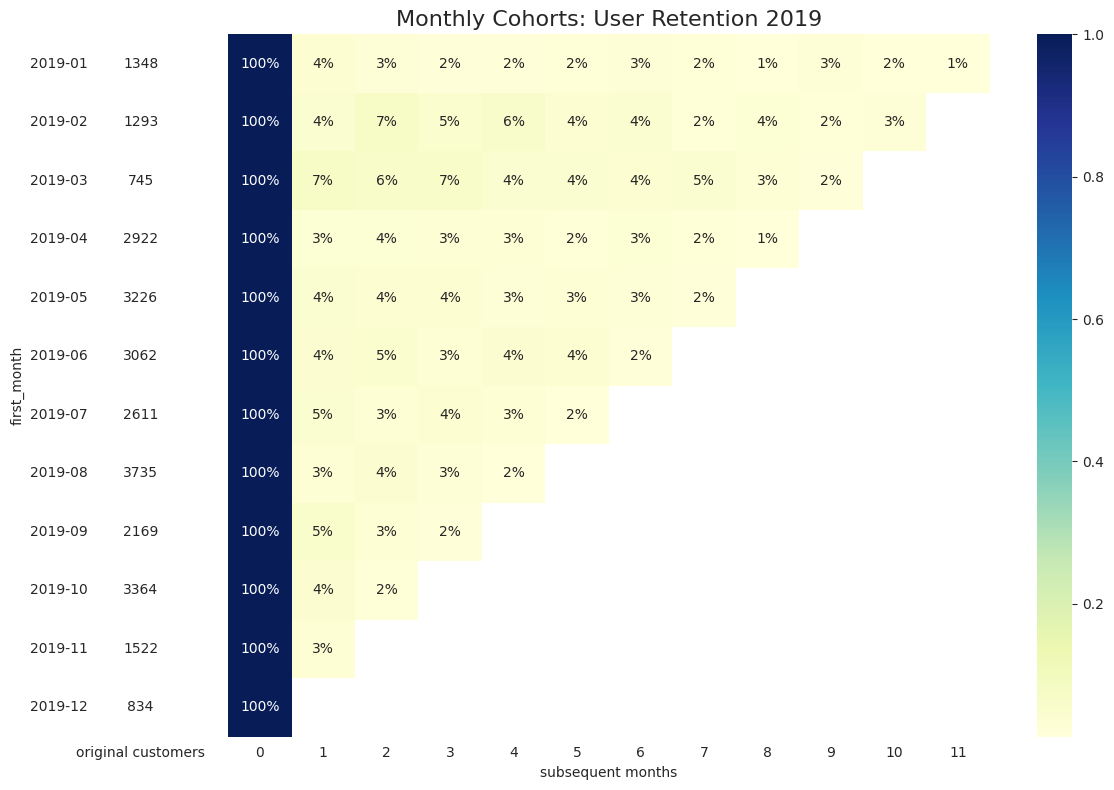

In [ ]:
# Vẽ biểu đồ cohort
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # retention matrix
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='YlGnBu',
                ax=ax[1])
    ax[1].set_title('Monthly Cohorts: User Retention 2019', fontsize=16)
    ax[1].set(xlabel='subsequent months',
              ylabel='')

    # cohort size
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'original customers'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                alpha=0.5,
                ax=ax[0])

    fig.tight_layout()

>- **Notes:**
>>- Retention 2019 và 2022 không có nhiều sự thay đổi, do thị trường phim mới hồi phục nên chưa có nhiều thời gian để công ty cải thiện
>>- Lý do retention thấp mặc dù rõ ràng 60-65% traffic có chạy trong năm 2022?

### Compare: Retention of promotion customers & organic customers

In [ ]:
# By payment method
df_pie_promo = (
    df_join_all[(df_join_all['status_id'] == 1) & (df_join_all['time'] > '2022-01-01')]
    .groupby('type')
    .agg(total_ticket = ('customer_id','nunique'))
    .sort_values(by='total_ticket', ascending=True)
    .reset_index()
    )

In [ ]:
df_pie_promo

,type,total_ticket
0,non-promotion,27672
1,promotion,47507


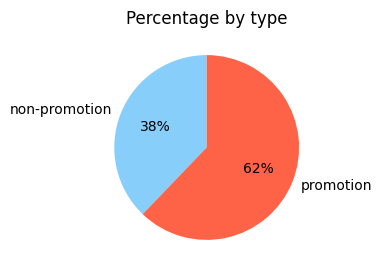

In [ ]:
# pie
plt.figure(figsize=(6,3))
plt.pie(df_pie_promo['total_ticket'],
        labels= df_pie_promo['type'],
        autopct='%1.0f%%',
        colors=df_pie_promo['type'].replace({'promotion': 'tomato', 'non-promotion': 'lightskyblue'}),
        startangle=90
        )
plt.title('Percentage by type')
plt.show()

In [ ]:
# Phân biệt nhóm đến từ promotion và nhóm organic: dựa trên vé đầu tiên ( first order )

In [ ]:
# Đánh số thứ tự các ticket của khách hàng:

In [ ]:
df_data_check = (
    df_join_all[(df_join_all['status_id'] == 1) & (df_join_all['time'] > '2022-01-01')][['customer_id','ticket_id','time','type']]
    .sort_values(by=['customer_id','time'])
)

In [ ]:
df_data_check.head(10)

,customer_id,ticket_id,time,type,row_number
66484,100003,34c4764b4afa000af4c33a525f20eace,2022-05-22 12:52:12.105,non-promotion,1
10001,100004,1c4aa39842bfc83dbb5856c25a33d9cb,2022-12-20 06:26:21.373,non-promotion,1
108794,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,promotion,1
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,promotion,1
5585,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,promotion,2
69405,100013,f95441286dcfa045f61a5760662616e1,2022-05-05 12:22:44.587,non-promotion,1
140483,100018,1e40fb2d0f6264ed3127f79b1a12c9c9,2022-09-07 21:13:17.896,non-promotion,1
90595,100018,9a959ff1649950949ff2c0aff4b62205,2022-11-19 16:25:43.981,promotion,2
35270,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,promotion,1
16649,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,promotion,1


In [ ]:
# Đánh số thứ tự các ticket của khách hàng:

df_data_check['row_number'] = df_data_check.groupby('customer_id').cumcount() + 1

In [ ]:
# Số KH có first payment là promotion:
df_data_check[(df_data_check['type'] == 'promotion') & (df_data_check['row_number'] == 1)]['customer_id'].nunique()

46189

In [ ]:
46189/47507

0.9722567200623066

In [ ]:
# Có 97% KH mới đến từ promotion trong nhóm KH có tham gia promotion --> Retention là bao nhiêu?

In [ ]:
df_first_promo_list = df_data_check[ (df_data_check['type'] == 'promotion') & df_data_check['row_number'] == 1]['customer_id']
df_first_promo_list.drop_duplicates(inplace=True)

df_first_promo_check = pd.merge(df_data_check, df_first_promo_list, on='customer_id', how='inner')

/tmp/ipykernel_6155/1669032904.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_promo_list.drop_duplicates(inplace=True)


In [ ]:
(
    df_first_promo_check[ df_first_promo_check['row_number'] == 2 ]['customer_id'].nunique()
/
    df_first_promo_check['customer_id'].nunique()
)


0.134793197836067

In [ ]:
# 13% KH quay lại kể từ lần đầu tham gia promotion ( tỷ lệ chuyển đổi = 13%)